
# Step 1 — Exploratory Data Analysis (EDA) on the Adult (Census Income) Dataset

**Goal:** Predict whether annual income exceeds $50K based on 1994 U.S. Census data.

**Type:** Binary Classification  
- **Class 1 → >50K** (positive class — our prediction target)  
- **Class 0 → ≤50K** (negative class)

We'll explore the data to understand its structure, spot issues, visualize relationships, and summarize insights.


In [17]:
# 1) Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 1. Load the dataset

We'll load the data from `adult.data` (the main file in the ZIP).  
Column names are extracted from the official dataset description.


In [18]:
# Define column names from adult.names file (as per UCI documentation)
cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load the dataset (adult.data)
df = pd.read_csv('../final/data/adult.data', names=cols)
print('Shape:', df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



## 2. Data Overview

We'll check basic info like types, null counts, and sample rows to understand the dataset.


In [3]:
df.info()
print('\nMissing values per column:')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Missing values per column:
age               0
workclass         0
fnlwgt            0
educa


## 3. Unique Values per Column

Helps identify categorical features.


In [4]:
df.nunique().sort_values(ascending=False)

fnlwgt            21648
capital-gain        119
hours-per-week       94
capital-loss         92
age                  73
native-country       42
education            16
education-num        16
occupation           15
workclass             9
marital-status        7
relationship          6
race                  5
sex                   2
income                2
dtype: int64


## 4. Descriptive Statistics (Numerical Features)


In [5]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



## 5. Target Variable Distribution
There is imbalance because most people earn ≤50.


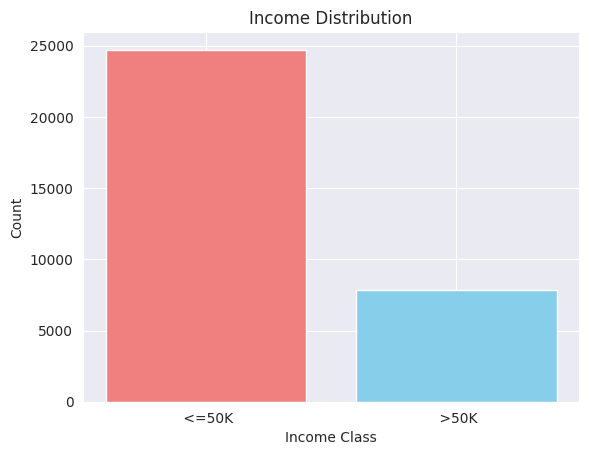

income
<=50K    75.919044
>50K     24.080956
Name: count, dtype: float64


In [7]:
target_counts = df['income'].value_counts().sort_index()
plt.bar(target_counts.index, target_counts.values, color=['lightcoral', 'skyblue'])
plt.title('Income Distribution')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.show()

print(target_counts / len(df) * 100)


## 6. Distribution of Numerical Features


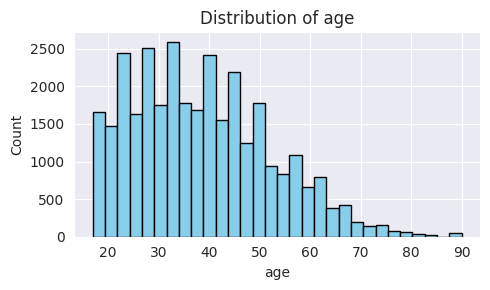

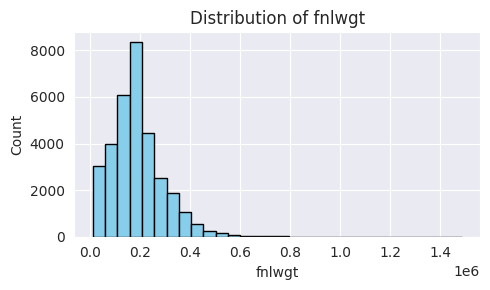

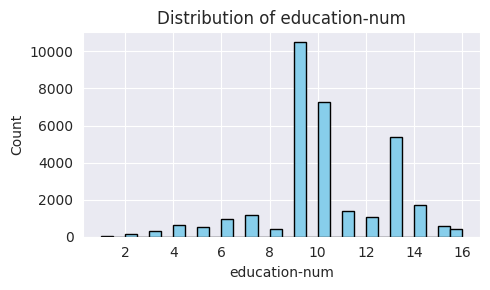

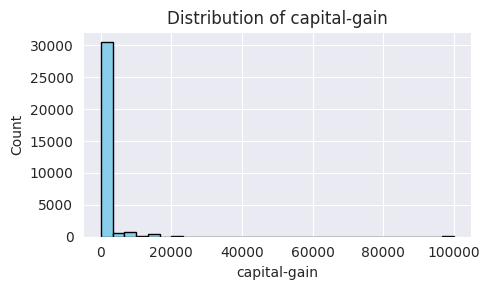

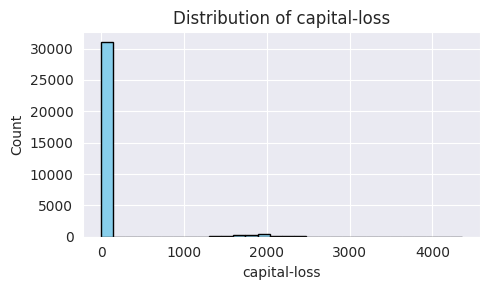

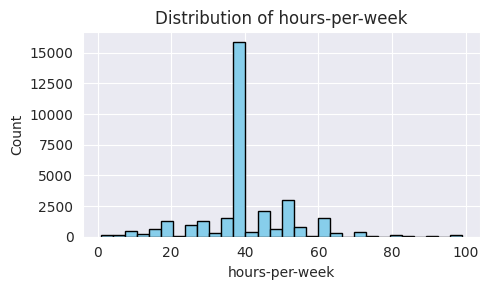

In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()



## 7. Outliers via Boxplots


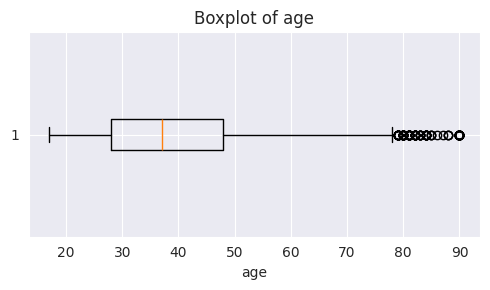

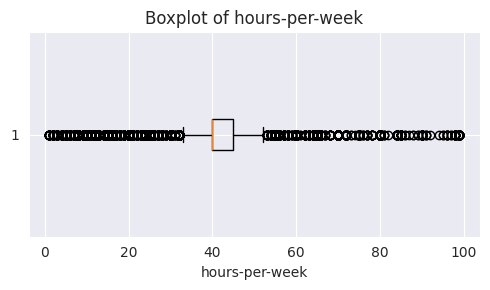

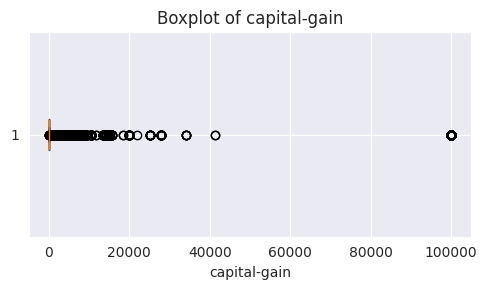

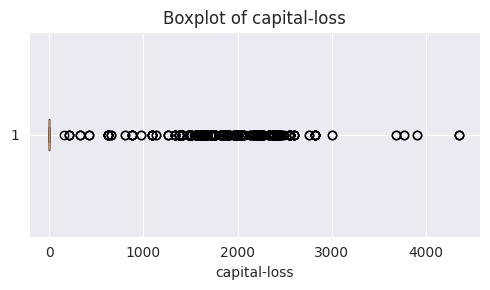

In [9]:
for col in ['age', 'hours-per-week', 'capital-gain', 'capital-loss']:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()



## 8. Categorical Feature Distributions


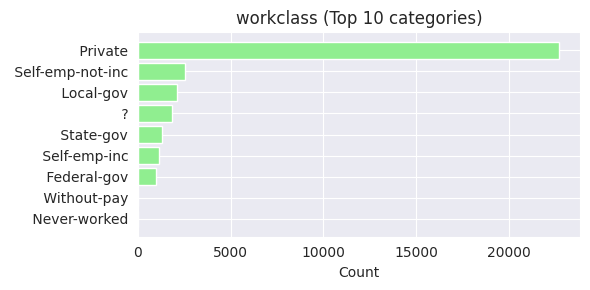

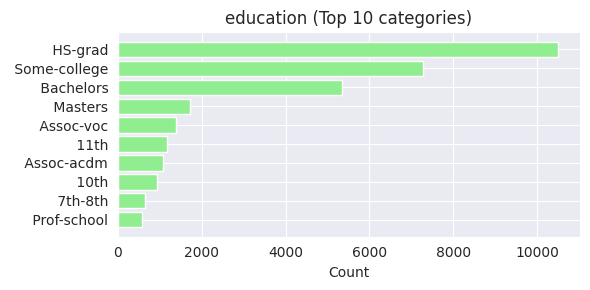

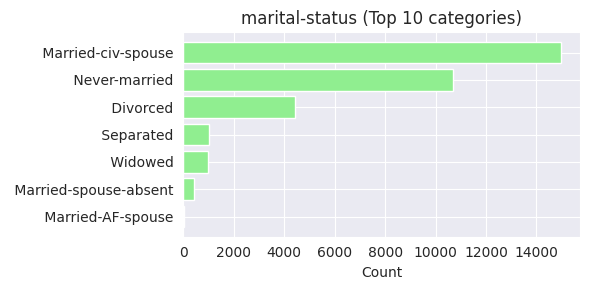

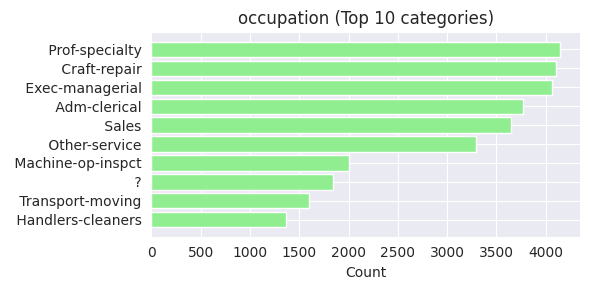

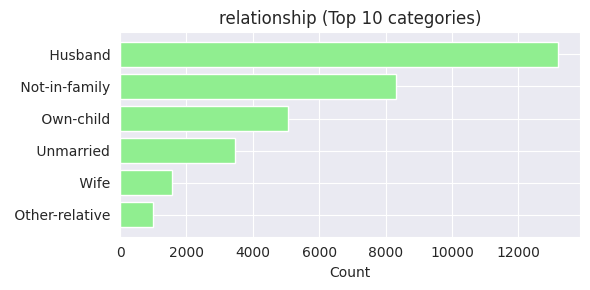

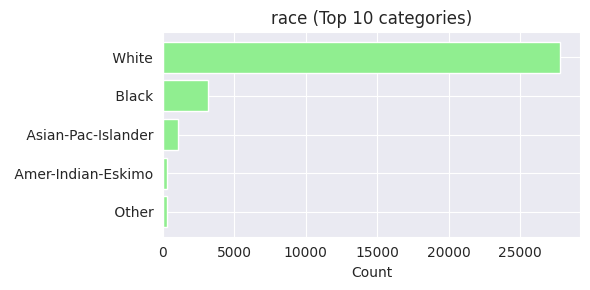

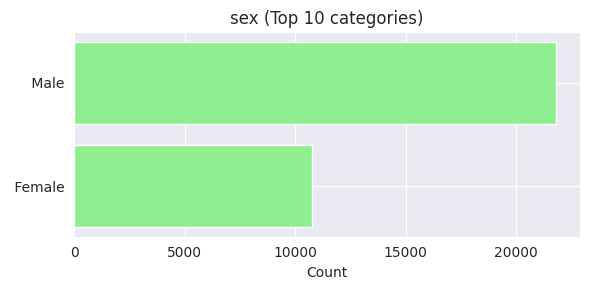

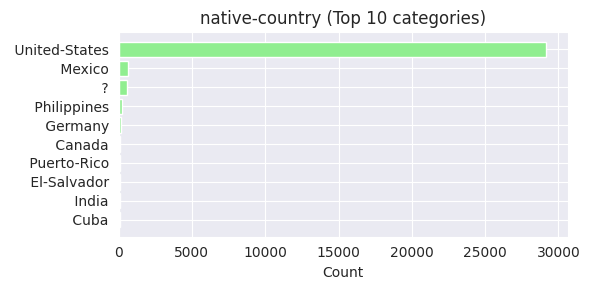

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns.drop('income')

for col in cat_cols:
    counts = df[col].value_counts().head(10)
    plt.figure(figsize=(6,3))
    plt.barh(counts.index[::-1], counts.values[::-1], color='lightgreen')
    plt.title(f'{col} (Top 10 categories)')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()


## 9. Correlation Matrix (Numerical Features)

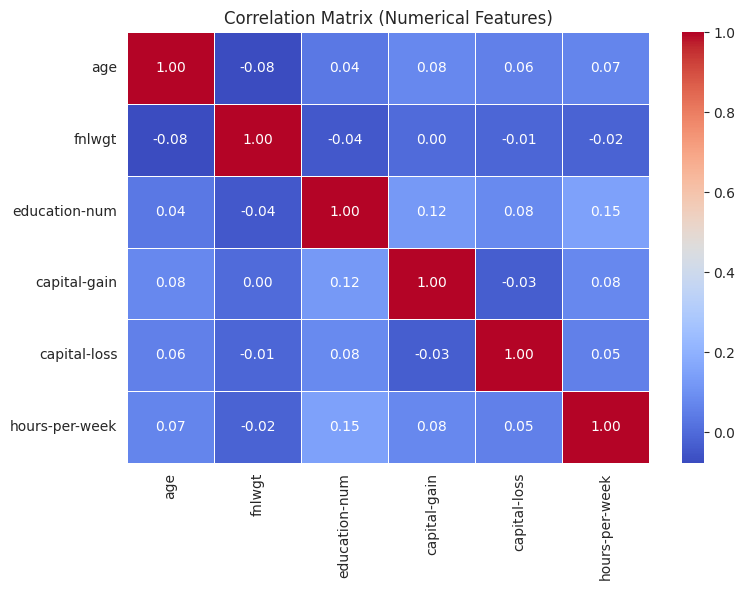

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()



## 10. Relationships Between Key Features and Income


<Figure size 600x300 with 0 Axes>

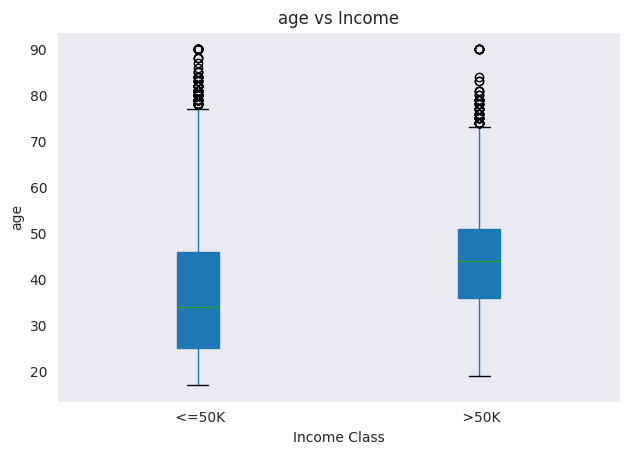

<Figure size 600x300 with 0 Axes>

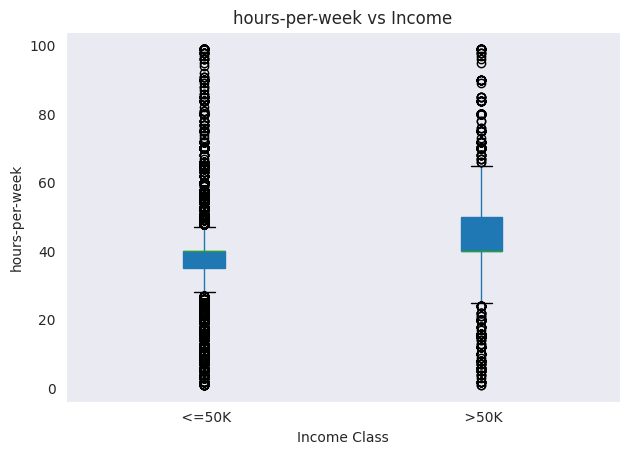

<Figure size 600x300 with 0 Axes>

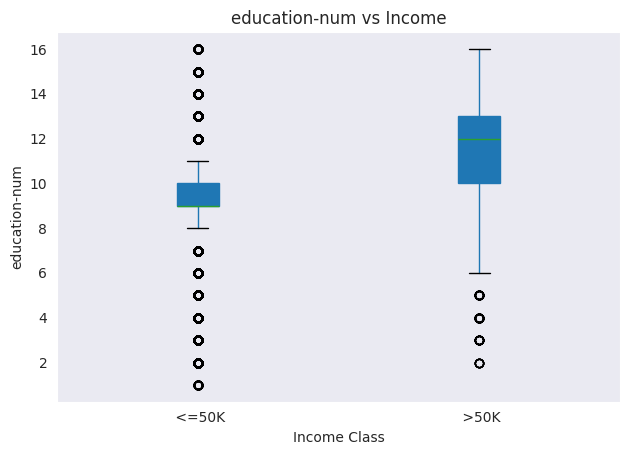

In [16]:
y = df['income'].map({'<=50K': 0, '>50K': 1})

for col in ['age', 'hours-per-week', 'education-num']:
    plt.figure(figsize=(6,3))
    df.boxplot(column=col, by='income', grid=False, patch_artist=True)
    plt.title(f'{col} vs Income')
    plt.suptitle('')
    plt.xlabel('Income Class')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 11. EDA Summary

- **Shape:** 48,842 rows × 15 columns  
- **Features:** 14 input + 1 target (`income`)  
- **Missing Values:** `workclass`, `occupation`, `native-country` have NaNs (previously `'?'`).  
- **Class Balance:** ~75% earn ≤50K, 25% >50K.  
- **Numerical Patterns:** Older people and those working longer hours tend to earn more.  
- **Categorical Trends:** Higher education, managerial/professional jobs, and males are more likely >50K.  
- **Outliers:** Extreme values in `capital-gain` and `capital-loss` (most people have 0).

This completes **Step 1 — Data Understanding & EDA.**
